In [ ]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle

from thesis_project.models.keyword_spotting.base_schema import KeyWordSpottingBaseConfig
from thesis_project.models.keyword_spotting.dynamic_schema import DynamicTrainingConfig

from thesis_project.training.key_word_spotting.validate_model import validate_model
from thesis_project.utils.compute_macs import compute_macs_base_model, compute_avg_rank_from_macs


#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

In [63]:
# Compute expected rank statistics from a dynamic experiment folder.
# The CSV stores ranks in a `rank` column and may contain either scalar ranks
# or per-stack ranks serialized as list-like values.


def compute_expected_rank_and_quantiles(
    per_sample_df_or_path,
    max_rank_cap: Optional[float] = None,
) -> Tuple[float, float, float, float, float]:
    if isinstance(per_sample_df_or_path, (str, Path)):
        per_sample_path = Path(per_sample_df_or_path)
        per_sample_df = pd.read_csv(per_sample_path)
    else:
        per_sample_path = None
        per_sample_df = per_sample_df_or_path

    rank_column = "rank" if "rank" in per_sample_df.columns else "rank_used"

    def _cap_rank(v: float) -> float:
        if max_rank_cap is None:
            return float(v)
        return float(min(max_rank_cap, float(v)))

    def _rank_to_scalar(value: Any) -> float:
        if pd.isna(value):
            return np.nan

        if isinstance(value, str):
            value = value.strip()
            if value.startswith("[") and value.endswith("]"):
                value = json.loads(value)

        if isinstance(value, np.ndarray):
            value = value.tolist()

        if isinstance(value, (list, tuple)):
            if len(value) == 0:
                return np.nan
            capped_values = [_cap_rank(float(v)) for v in value]
            return float(np.mean(capped_values))

        return _cap_rank(float(value))

    sample_ranks = per_sample_df[rank_column].map(_rank_to_scalar).dropna()
    if sample_ranks.empty:
        raise ValueError(f"No valid rank values found in {per_sample_path or 'per_sample_df'}")

    q25, q50, q75 = sample_ranks.quantile([0.25, 0.5, 0.75]).tolist()
    expected_rank = float(sample_ranks.mean())

    avg_acc = float("nan")
    if "correct" in per_sample_df.columns:
        avg_acc = float(per_sample_df["correct"].mean() * 100)
    elif "acc" in per_sample_df.columns:
        avg_acc = float(per_sample_df["acc"].mean())

    return expected_rank, float(q25), float(q50), float(q75), avg_acc

In [64]:
# folder with dynamic model checkpoints
parent_dir = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/"
sweep_folders = [
'one_sided_mse_rf_2_4_6_avg',
'ce_weighted_rank_rf_2_sub',
'one_sided_mse_rf_2_4_6_sub',
'avg_rank_rf_2_sub',
'batch_mean_mse_rf_2_sub'
]
experiment_folders = []
for sweep in sweep_folders:
    sweep_dir = os.path.join(parent_dir, sweep)
    if os.path.isdir(sweep_dir):
        for exp in os.listdir(sweep_dir):
            exp_path = os.path.join(sweep_dir, exp)
            if os.path.isdir(exp_path):
                experiment_folders.append(exp_path)
experiment_folders.sort(key=lambda x: os.path.getmtime(x), reverse=False)

In [65]:
all_sweep_results = []

for exp_folder in experiment_folders:
    config_path = Path(exp_folder) / "config.json"
    with open(config_path, "r") as f:
        experiment_config = json.load(f)

    runtime_info_path = Path(exp_folder) / "runtime_info.json"
    runtime_info = {}
    with open(runtime_info_path, "r") as f:
        runtime_info = json.load(f)
    
    per_sample_df_path = Path(exp_folder) / "per_sample_df.csv"
    if not per_sample_df_path.exists():
        print(f"Warning: Could not find per_sample_df.csv in {exp_folder}, skipping expected rank computation")
        continue

    per_sample_df = pd.read_csv(per_sample_df_path)
    expected_rank, q25, q50, q75, avg_acc = compute_expected_rank_and_quantiles(per_sample_df,max_rank_cap=30)

    router_cfg = experiment_config.get("router", {})
    loss_cfg = experiment_config.get("loss", {})

    all_sweep_results.append({
        "experiment_folder": exp_folder,
        "expected_rank": expected_rank,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "avg_acc": avg_acc,
        "use_global_rank": router_cfg.get("use_global_rank"),
        "num_rank_outputs": router_cfg.get("num_rank_outputs"),
        "pool_mode": router_cfg.get("pool_mode"),
        "pool_reduction_factor": router_cfg.get("pool_reduction_factor"),
        "rank_loss_weight": loss_cfg.get("rank_loss_weight"),
        "rank_loss_mode": loss_cfg.get("rank_loss_mode"),
        "rank_target": loss_cfg.get("base_model_rank_reference") if loss_cfg.get("rank_loss_mode") not in ["avg_rank", "ce_weighted_rank"] else None,
        "router_macs": runtime_info["macs"]["router"],
        #"runtime_info": runtime_info
    })
#all_sweep_results


In [66]:
all_sweep_results

[{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
  'expected_rank': 19.910843330381894,
  'q25': 16.660258293151855,
  'q50': 18.527493476867676,
  'q75': 21.767035484313965,
  'avg_acc': 86.83647102251754,
  'use_global_rank': True,
  'num_rank_outputs': 1,
  'pool_mode': 'subsample',
  'pool_reduction_factor': 2,
  'rank_loss_weight': 1.0,
  'rank_loss_mode': 'avg_rank',
  'rank_target': None,
  'router_macs': 785712.0},
 {'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_002',
  'expected_rank': 19.659986658543403,
  'q25': 16.924882253011067,
  'q50': 18.285550435384113,
  'q75': 21.02408742904663,
  'avg_acc': 86.63713547434477,
  'use_global_rank': False,
  'num_rank_outputs': 3,
  'pool_mode': 'subsample',
  'pool_reduction_factor': 2,
  'rank_loss_weight': 1.0,
  'rank_loss_mode': 'avg_rank',
  'rank_target': None,
  'rou

In [67]:
# function that filters sweep results by loss type, target rank, router outputs, pool mode, and reduction factor
def filter_sweep_results(
    sweep_results: List[Dict[str, Any]],
    loss_types=['avg_rank', 'batch_mean_mse', 'ce_weighted_rank', 'one_sided_mse'],
    router_num_rank_outputs=[1, 3],
    rank_targets=[None, 10, 20, 30],
    pool_modes=['avg', 'max', 'subsample'],
    pool_reduction_factors=[2, 4, 6],
) -> List[Dict[str, Any]]:
    
    # check that None is in the target ranks if any of the loss types that don't use a fixed target rank are included in the filter criteria
    if any(loss in loss_types for loss in ["avg_rank", "ce_weighted_rank"]):
        assert None in rank_targets, "Filter criteria includes loss types that don't use a fixed target rank (avg_rank, ce_weighted_rank) but None is not included in the target ranks filter criteria. Please include None in target_ranks to allow filtering for these loss types."

    filtered_results = []
    for result in sweep_results:
        if result.get("rank_loss_mode") not in loss_types:
            continue
        if result.get("num_rank_outputs") not in router_num_rank_outputs:
            continue
        if result.get("rank_target") not in rank_targets:
            continue
        if result.get("pool_mode") not in pool_modes:
            continue
        if result.get("pool_reduction_factor") not in pool_reduction_factors:
            continue
        filtered_results.append(result)

    assert filtered_results, "No results matched the specified filter criteria. Please check the available values in the sweep results."
    return filtered_results

In [156]:
# fin all unique values for loss types and router modes
loss_types = sorted(set(r["rank_loss_mode"] for r in all_sweep_results))
router_num_rank_outputs = sorted(set(r["num_rank_outputs"] for r in all_sweep_results))
# different weight values for the rank loss
rank_loss_weights = sorted(set(r["rank_loss_weight"] for r in all_sweep_results))
# base_mode_rank_references
rank_targets = set(r["rank_target"] for r in all_sweep_results)
pool_modes = sorted(set(r["pool_mode"] for r in all_sweep_results))
# check the span of q25 and q75 values across the sweep results to get a sense of the rank distribution span
q25_values = [r["q25"] for r in all_sweep_results]
q75_values = [r["q75"] for r in all_sweep_results]
print(f"Rank q25 values span from {min(q25_values):.2f} to {max(q25_values):.2f}")
print(f"Rank q75 values span from {min(q75_values):.2f} to {max(q75_values):.2f}")

Rank q25 values span from 5.36 to 30.00
Rank q75 values span from 7.37 to 30.00


In [69]:
rank_targets

{10.0, 20.0, 30.0, None}

In [70]:
pool_modes

['avg', 'subsample']

In [71]:
# Helper function to compute MACs from base_model_info dict (instead of model instance)
def compute_macs_from_info(base_model_info: dict, time_steps: int, rank_pr_stack: list) -> int:
    """
    Compute MACs for the base model given base_model_info dict and ranks per stack.
    Args:
        base_model_info: Dictionary with keys: n_stacks, n_channels_ext, n_channels_int, n_blocks_pr_stack
        time_steps: Number of time steps in the input
        rank_pr_stack: List of ranks for each stack in the backbone
        
    Returns:
        Total MACs for the base model
    """
    assert len(rank_pr_stack) == base_model_info["backbone"]["n_stacks"], \
        f"Length of rank_pr_stack ({len(rank_pr_stack)}) must match n_stacks ({base_model_info['backbone']['n_stacks']})"
    
    # total MACs across all stacks = (MACs 1 rank layer) * 2 layers per block * n_blocks_pr_stack * sum of ranks across stacks
    macs = time_steps * (base_model_info['backbone']['n_channels_ext'] + base_model_info['backbone']['n_channels_int'])
    macs *= 2 * base_model_info['backbone']['n_blocks_pr_stack']
    macs *= sum(rank_pr_stack)
    return int(macs)

In [72]:
# Helper to compute effective rank accounting for router overhead
def compute_effective_rank(expected_rank, router_macs, base_model):
    """
    Convert expected_rank (dynamic model avg rank) to effective_rank 
    (equivalent base model rank accounting for router overhead).
    
    Args:
        expected_rank: Average rank used by the dynamic model
        runtime_info: Runtime info dict from experiment (contains router MACs)
        base_model: Base model instance for MAC calculations
        
    Returns:
        Effective rank (equivalent base model rank)
    """
    try:
        n_stacks = len(base_model.backbone)
        # Compute MACs for dynamic model at expected_rank
        # Each stack uses expected_rank on average
        ranks_per_stack = [int(expected_rank)] * n_stacks
        dynamic_model_macs = compute_macs_base_model(
            base_model,
            time_steps=63,
            rank_pr_stack=ranks_per_stack
        )
        
        # Total MACs = dynamic model + router overhead
        total_macs = dynamic_model_macs + router_macs
        
        # Convert back to equivalent base model rank
        effective_rank = compute_avg_rank_from_macs(
            base_model,
            time_steps=63,
            macs=total_macs,
            num_stacks=n_stacks
        )
        
        return effective_rank
    
    except Exception as e:
        print(f"Warning: Could not compute effective rank: {e}")
        return expected_rank  # Fallback to expected rank

In [73]:
# Load base model results for Pareto front overlay

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
base_model_info = json.load(open(os.path.join(BASE_MODEL_DIR, "base_config.json"), "r"))
MODEL_CHECKPOINT = BASE_MODEL_DIR + "best_model.pth"

base_model = KWSBase(cfg)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT))

# Load per-sample results from CSV files, this the augmented CSV where 
# base model is evaluated on all validation sets and SNRs
df_base = pd.read_csv(BASE_MODEL_DIR + "per_sample_results_comb_1_golden.csv")
# Get the length of a single validation set
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")
# Assign consistent IDs
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set
df_base['model_name'] = 'base'
print(f"\nLoaded base model results from: {BASE_MODEL_DIR}")
print(f"DataFrame shape: {df_base.shape}")
print(f"Unique ranks: {len(df_base['rank'].unique())}")
print(f"Unique SNRs: {len(df_base['snr_eval'].unique())}")

Length of single validation set: 4515

Loaded base model results from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
DataFrame shape: (10402560, 13)
Unique ranks: 64
Unique SNRs: 6


In [74]:
base_model_info["backbone"]["n_stacks"]

3

In [75]:
# Get base_model_info from the first sweep result
# Compute MACs for rank 30
rank_30_macs = compute_macs_from_info(
    base_model_info, 
    time_steps=63, 
    rank_pr_stack=[30] * base_model_info["backbone"]['n_stacks']
)

full_rank_macs = compute_macs_from_info(
    base_model_info, 
    time_steps=63, 
    rank_pr_stack=[128] * base_model_info["backbone"]['n_stacks']
)

# Divide by 2 since  full rank would not be r * (C_in + C_out) but
# just C_in * C_out (since it's not low rank), so we need to divide by 2 to get the break-even point for low rank
# which is also the point where the router overhead would make it not worth it to go above that rank
full_rank_macs = full_rank_macs // 2  # Divide by 2 since this is break even for low rank

print(f"Rank 30 MACs: {rank_30_macs:,} ({rank_30_macs/1e6:.2f}M)")
print(f"Full Rank MACs: {full_rank_macs:,} ({full_rank_macs/1e6:.2f}M)")

Rank 30 MACs: 8,709,120 (8.71M)
Full Rank MACs: 18,579,456 (18.58M)


In [76]:
def prepare_base_model_points_and_pareto(
    df_base: pd.DataFrame,
    x_axis: str = "rank",
    include_silence: bool = True,
    base_model_info: dict | None = None,
    time_steps: int = 63,
):
    """
    Prepare base-model points and Pareto front for plotting.

    Parameters
    ----------
    df_base : pd.DataFrame
        Base-model per-sample results with at least columns ['rank', 'correct'].
    x_axis : str
        Either 'rank' or 'macs'.
    include_silence : bool
        Whether to include silence labels.
    base_model_info : dict or None
        Required when x_axis='macs'. Used by compute_macs_from_info.
    time_steps : int
        Time steps passed to compute_macs_from_info when x_axis='macs'.

    Returns
    -------
    all_points_df : pd.DataFrame
        Columns: ['rank', 'acc', 'x', 'is_pareto']
    pareto_points_df : pd.DataFrame
        Subset of all_points_df containing only Pareto-optimal points
    """
    df = df_base.copy()

    if not include_silence and "label" in df.columns:
        silence_mask = df["label"].astype(str).str.lower().str.contains("silence", na=False)
        df = df.loc[~silence_mask].copy()

    all_points_df = (
        df.groupby("rank", as_index=False)["correct"]
        .mean()
        .rename(columns={"correct": "acc"})
        .sort_values("rank")
        .reset_index(drop=True)
    )
    all_points_df["acc"] = all_points_df["acc"] * 100

    if x_axis == "rank":
        all_points_df["x"] = all_points_df["rank"].astype(float)

    elif x_axis == "macs":
        if base_model_info is None:
            raise ValueError("base_model_info must be provided when x_axis='macs'")

        all_points_df["x"] = all_points_df["rank"].apply(
            lambda rank: compute_macs_from_info(
                base_model_info,
                time_steps=time_steps,
                rank_pr_stack=[int(rank)] * base_model_info["backbone"]["n_stacks"],
            ) / 1e6
        )
    else:
        raise ValueError(f"Unsupported x_axis: {x_axis}. Expected 'rank' or 'macs'")

    # Pareto-optimal points:
    # keep point if it achieves strictly higher accuracy than any lower-x point seen so far
    pareto_mask = []
    best_acc_so_far = -np.inf

    for _, row in all_points_df.sort_values("x").iterrows():
        if row["acc"] > best_acc_so_far:
            pareto_mask.append(True)
            best_acc_so_far = row["acc"]
        else:
            pareto_mask.append(False)

    all_points_df = all_points_df.sort_values("x").reset_index(drop=True)
    all_points_df["is_pareto"] = pareto_mask

    pareto_points_df = all_points_df.loc[all_points_df["is_pareto"]].copy().reset_index(drop=True)

    return all_points_df, pareto_points_df

In [77]:
all_sweep_results[0]

{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
 'expected_rank': 19.910843330381894,
 'q25': 16.660258293151855,
 'q50': 18.527493476867676,
 'q75': 21.767035484313965,
 'avg_acc': 86.83647102251754,
 'use_global_rank': True,
 'num_rank_outputs': 1,
 'pool_mode': 'subsample',
 'pool_reduction_factor': 2,
 'rank_loss_weight': 1.0,
 'rank_loss_mode': 'avg_rank',
 'rank_target': None,
 'router_macs': 785712.0}

In [509]:
def plot_rank_vs_acc_by_mode(
    sweep_results,
    include_router_overhead=True,
    x_axis='macs',
    base_pareto_alpha=0.5,
    x_axis_cut_off_ranks=(5, 30),
    plot_title=None,
    alpha_above_pareto=0.85,
    alpha_below_pareto=0.20,
    fade_points_after_rank=30, # increasing rank beyond this value is irrelevant because static basline would be used. 
):
    # Get unique loss types and router modes
    loss_types = sorted(set(r["rank_loss_mode"] for r in sweep_results))
    router_num_rank_outputs = sorted(set(r["num_rank_outputs"] for r in sweep_results))

    # Get unique values for visual encoding
    target_ranks = sorted({r["rank_target"] for r in sweep_results if r["rank_target"] is not None})
    rank_loss_weights = sorted({
        r["rank_loss_weight"]
        for r in sweep_results
        if r["rank_loss_weight"] is not None
    })

    # Color map for target ranks
    colors = plt.cm.viridis(np.linspace(0, 1, len(target_ranks)))
    color_map = {rank: colors[i] for i, rank in enumerate(target_ranks)}
    none_target_color = "tab:blue"
    base_pareto_color = "gray"

    # Size map for rank_loss_weights
    min_size = 40
    max_size = 150
    if rank_loss_weights:
        min_w = min(rank_loss_weights)
        max_w = max(rank_loss_weights)
        denom = (max_w - min_w) if (max_w - min_w) != 0 else 1.0
        size_map = {
            weight: min_size + (max_size - min_size) * (weight - min_w) / denom
            for weight in rank_loss_weights
        }
    else:
        size_map = {}

    # Create subplots
    n_rows = len(loss_types)
    n_cols = len(router_num_rank_outputs)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.4 * n_cols, 7.2 * n_rows),
        squeeze=False,
        sharex=True,
        sharey='row',
    )

    def _rank_to_x(rank):
        if x_axis == 'rank':
            return float(rank)
        return compute_macs_from_info(
            base_model_info,
            time_steps=63,
            rank_pr_stack=[int(rank)] * base_model_info["backbone"]["n_stacks"],
        ) / 1e6

    # Visual cutoff only
    x_lo = _rank_to_x(x_axis_cut_off_ranks[0])
    x_hi = _rank_to_x(x_axis_cut_off_ranks[1])
    x_axis_label = 'Rank' if x_axis == 'rank' else 'MACs (millions)'

    # Base Pareto front
    _, base_pareto_df = prepare_base_model_points_and_pareto(
        df_base=df_base,
        x_axis=x_axis,
        include_silence=True,
        base_model_info=base_model_info,
        time_steps=63
    )
    base_pareto_df = base_pareto_df.copy()

    # Lookup static Pareto-front accuracy at a given x (step curve, where='post')
    pareto_x = base_pareto_df["x"].to_numpy()
    pareto_y = base_pareto_df["acc"].to_numpy()

    def _base_front_acc_at(x):
        idx = np.searchsorted(pareto_x, x, side="right") - 1
        if idx < 0:
            return float(pareto_y[0])
        return float(pareto_y[idx])

    processed_results = []

    for result in sweep_results:
        x_value = result["expected_rank"]
        q25_value = result["q25"]
        q75_value = result["q75"]
        avg_acc = result["avg_acc"]

        if include_router_overhead:
            x_value = compute_effective_rank(
                expected_rank=result["expected_rank"],
                router_macs=result["router_macs"],
                base_model=base_model
            )
            q25_value = compute_effective_rank(
                expected_rank=result["q25"],
                router_macs=result["router_macs"],
                base_model=base_model
            )
            q75_value = compute_effective_rank(
                expected_rank=result["q75"],
                router_macs=result["router_macs"],
                base_model=base_model
            )

        x_value = _rank_to_x(x_value)
        q25_value = _rank_to_x(q25_value)
        q75_value = _rank_to_x(q75_value)

        processed_results.append({
            "rank_loss_mode": result["rank_loss_mode"],
            "num_rank_outputs": result["num_rank_outputs"],
            "x_value": x_value,
            "q25_value": q25_value,
            "q75_value": q75_value,
            "avg_acc": avg_acc,
            "rank_target": result["rank_target"],
            "rank_loss_weight": result["rank_loss_weight"],
        })

    # Y-limits should depend only on what is visible in the chosen x-window,
    # while still plotting all data
    visible_accs = base_pareto_df.loc[
        (base_pareto_df["x"] >= x_lo) & (base_pareto_df["x"] <= x_hi),
        "acc"
    ].tolist()

    for result in processed_results:
        if x_lo <= result["x_value"] <= x_hi:
            visible_accs.append(result["avg_acc"] )

    if visible_accs:
        y_min = min(visible_accs)
        y_max = max(visible_accs)
    else:
        y_min = base_pareto_df["acc"].min()
        y_max = base_pareto_df["acc"].max()

    x_pad = 0.03 * (x_hi - x_lo if x_hi > x_lo else 1.0)
    y_pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)

    # Plot base Pareto front on all subplots
    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]

            ax.step(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                where="post",
                color=base_pareto_color,
                linewidth=2,
                alpha=base_pareto_alpha,
                label="Base Pareto Front",
                zorder=1
            )

            ax.scatter(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                color=base_pareto_color,
                s=16,
                alpha=base_pareto_alpha,
                zorder=1
            )

            ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)
            ax.grid(True, linestyle="-", alpha=0.3)
            ax.tick_params(axis='both', labelsize=14)
            if row_idx == n_rows - 1:
                ax.set_xlabel(x_axis_label, fontsize=14)
            if col_idx == 0:
                ax.set_ylabel('Accuracy (%)', fontsize=14)

    # Plot dynamic results
    for row_idx, loss_type in enumerate(loss_types):
        for col_idx, num_rank_output in enumerate(router_num_rank_outputs):
            ax = axes[row_idx, col_idx]

            if col_idx == 0:
                col_title = 'Global rank'
            elif col_idx == 1:
                col_title = 'Per-stack rank'
            else:
                col_title = f'Column {col_idx + 1}'

            pretty_loss_map = {
                'batch_mean_mse': 'MSE',
                'one_sided_mse': 'One Sided MSE',
            }
            pretty_loss = pretty_loss_map.get(loss_type, loss_type.replace('_', ' ').title())
            ax.set_title(f'{col_title} | {pretty_loss}', fontsize=14)

            filtered_results = [
                r for r in processed_results
                if r["rank_loss_mode"] == loss_type and r["num_rank_outputs"] == num_rank_output
            ]

            for result in filtered_results:
                x_value = result["x_value"]
                q25_value = result["q25_value"]
                q75_value = result["q75_value"]
                avg_acc = result["avg_acc"]
                target_rank = result["rank_target"]
                rank_loss_weight = result["rank_loss_weight"]

                point_color = none_target_color if target_rank is None else color_map[target_rank]
                point_size = size_map.get(rank_loss_weight, min_size)

                below_pareto = avg_acc < _base_front_acc_at(x_value)
                point_alpha = alpha_below_pareto if below_pareto else alpha_above_pareto
                span_alpha = 0.5 * point_alpha

                # quantile span
                ax.hlines(
                    avg_acc,
                    q25_value,
                    q75_value,
                    colors=point_color,
                    alpha=span_alpha,
                    linewidth=1.5,
                    zorder=2
                )

                x_mid = 0.5 * (q25_value + q75_value)

                ax.scatter(
                    x_mid,
                    avg_acc,
                    marker='|',
                    s=point_size * 1.0,   # scales with your dot size
                    color=point_color,
                    alpha=point_alpha,
                    linewidths=2,
                    zorder=3
                )

                # expected-rank point
                ax.scatter(
                    x_value,
                    avg_acc,
                    color=point_color,
                    s=point_size,
                    alpha=point_alpha,
                    edgecolors='black',
                    linewidth=1.2,
                    zorder=4
                )

            # Legend inside each subplot (bottom-right)
            legend_handles = [
                ax.plot([], [], color=base_pareto_color, linewidth=2, label='baseline Pareto front')[0],
                ax.plot([], [], color='black', linewidth=1.5, marker='|', markersize=10, label='IQR (Q25-Q75)')[0]
            ]
            if any(r['rank_target'] is None for r in processed_results):
                legend_handles.append(
                    ax.scatter([], [], s=70, color=none_target_color, edgecolors='black', linewidths=0.8, label='target=None')
                )
            for tr in target_ranks:
                legend_handles.append(
                    ax.scatter([], [], s=70, color=color_map[tr], edgecolors='black', linewidths=0.8, label=f'target={tr}')
                )
            for w in rank_loss_weights:
                legend_handles.append(
                    ax.scatter([], [], s=size_map.get(w, min_size), facecolors='none', edgecolors='black', linewidths=1.1, label=f'weight={w:g}')
                )

            ax.legend(
                handles=legend_handles,
                loc='lower right',
                frameon=True,
                fontsize=10,
                title='Target / Weight',
                title_fontsize=11,
                markerscale=1.0
            )

    if plot_title is not None:
        fig.suptitle(plot_title, fontsize=18, y=0.900)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
    else:
        plt.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

In [510]:
# # everything
# sweeps_for_plotting_1 = filter_sweep_results(
#     all_sweep_results,
#     loss_types = ['avg_rank', 'ce_weighted_rank', 'one_sided_mse', 'batch_mean_mse'],
#     router_num_rank_outputs = [1, 3],
#     rank_targets= [None, 10, 20, 30],
#     pool_modes = ['subsample'],
#     pool_reduction_factors = [2]
# )

In [517]:

# fig = plot_rank_vs_acc_by_mode(
#     sweeps_for_plotting_1,
#     include_router_overhead=True,
#     x_axis='macs',
#     base_pareto_alpha=0.5,
#     x_axis_cut_off_ranks=(5, 30),
#     plot_title="Dynamic KWS: Accuracy vs. Effective Rank (with Router Overhead)",
#     alpha_above_pareto=0.85,
#     alpha_below_pareto=0.20,
#     fade_points_after_rank=30
# )
# plt.show()


In [518]:
# loss functions with no rank target:
sweeps_for_plotting_2 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['avg_rank', 'ce_weighted_rank'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [None],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2]
)

In [519]:
len(sweeps_for_plotting_2)

20

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/rank_vs_accuracy_pareto_no_target_losses.png


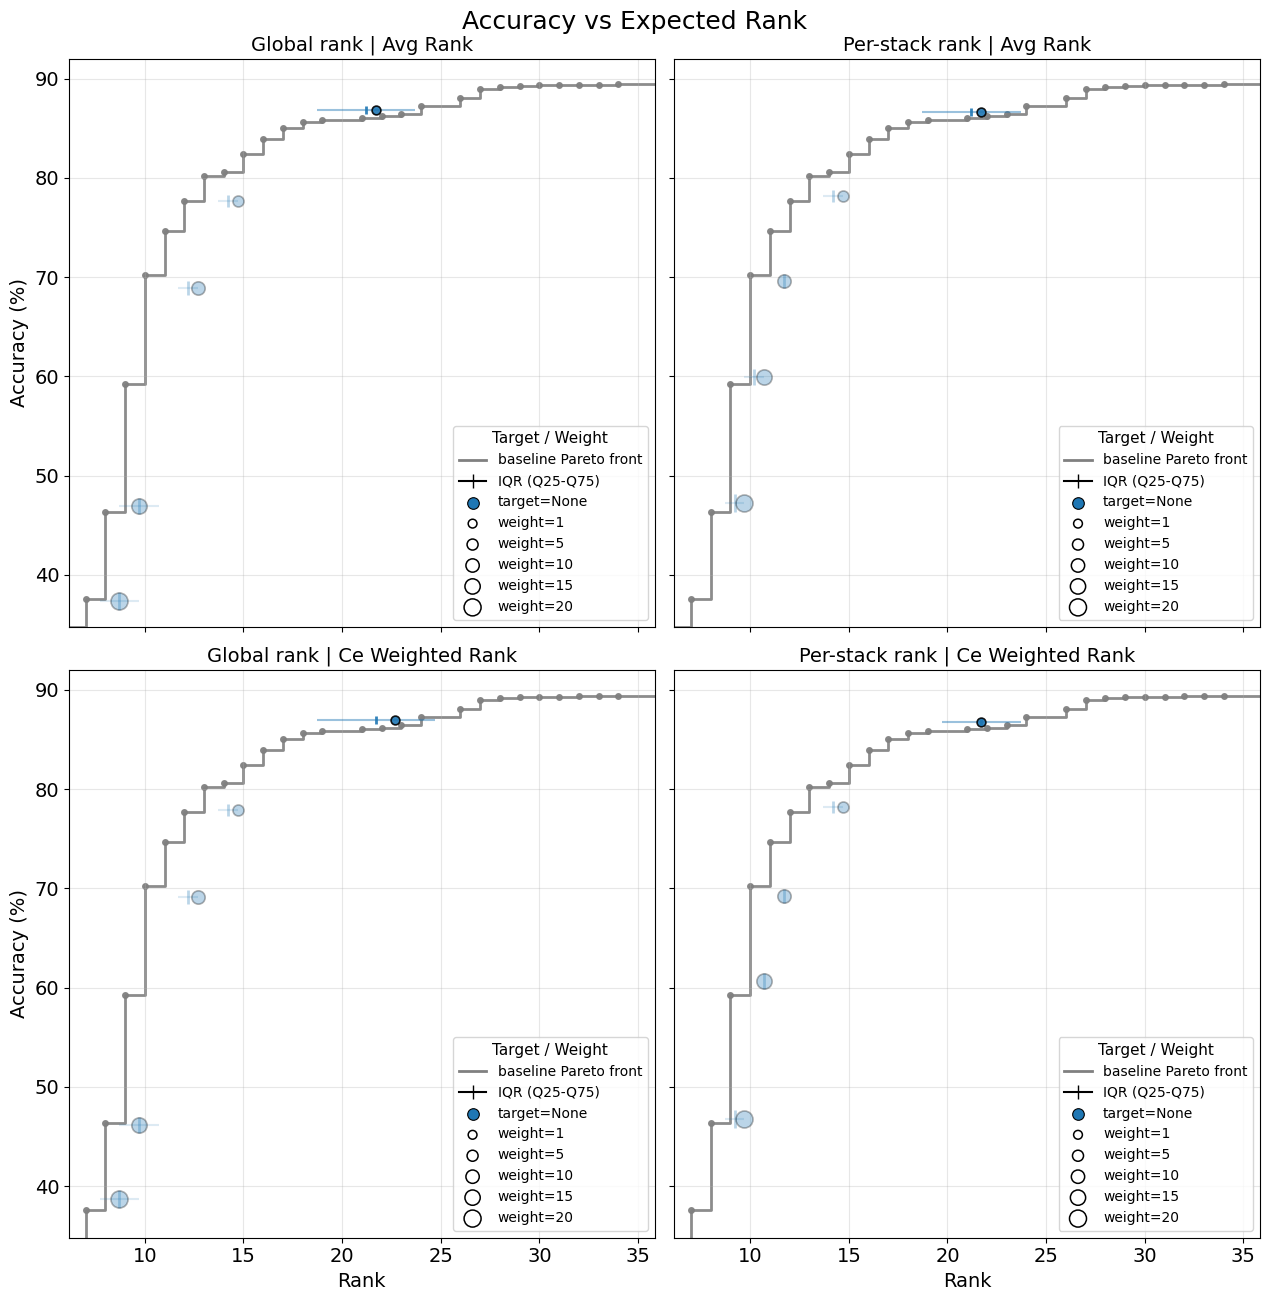

In [523]:
# Example usage + save figure (high DPI)
output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)

fig = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_2,
    include_router_overhead=True,
    x_axis='rank',
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(7, 35),
    plot_title='Accuracy vs Expected Rank',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / "rank_vs_accuracy_pareto_no_target_losses.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')
print(f"Saved figure to: {save_path}")

In [524]:
sweeps_for_plotting_3 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [10, 20, 30],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2]
)

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/rank_vs_accuracy_pareto_targeted_losses.png


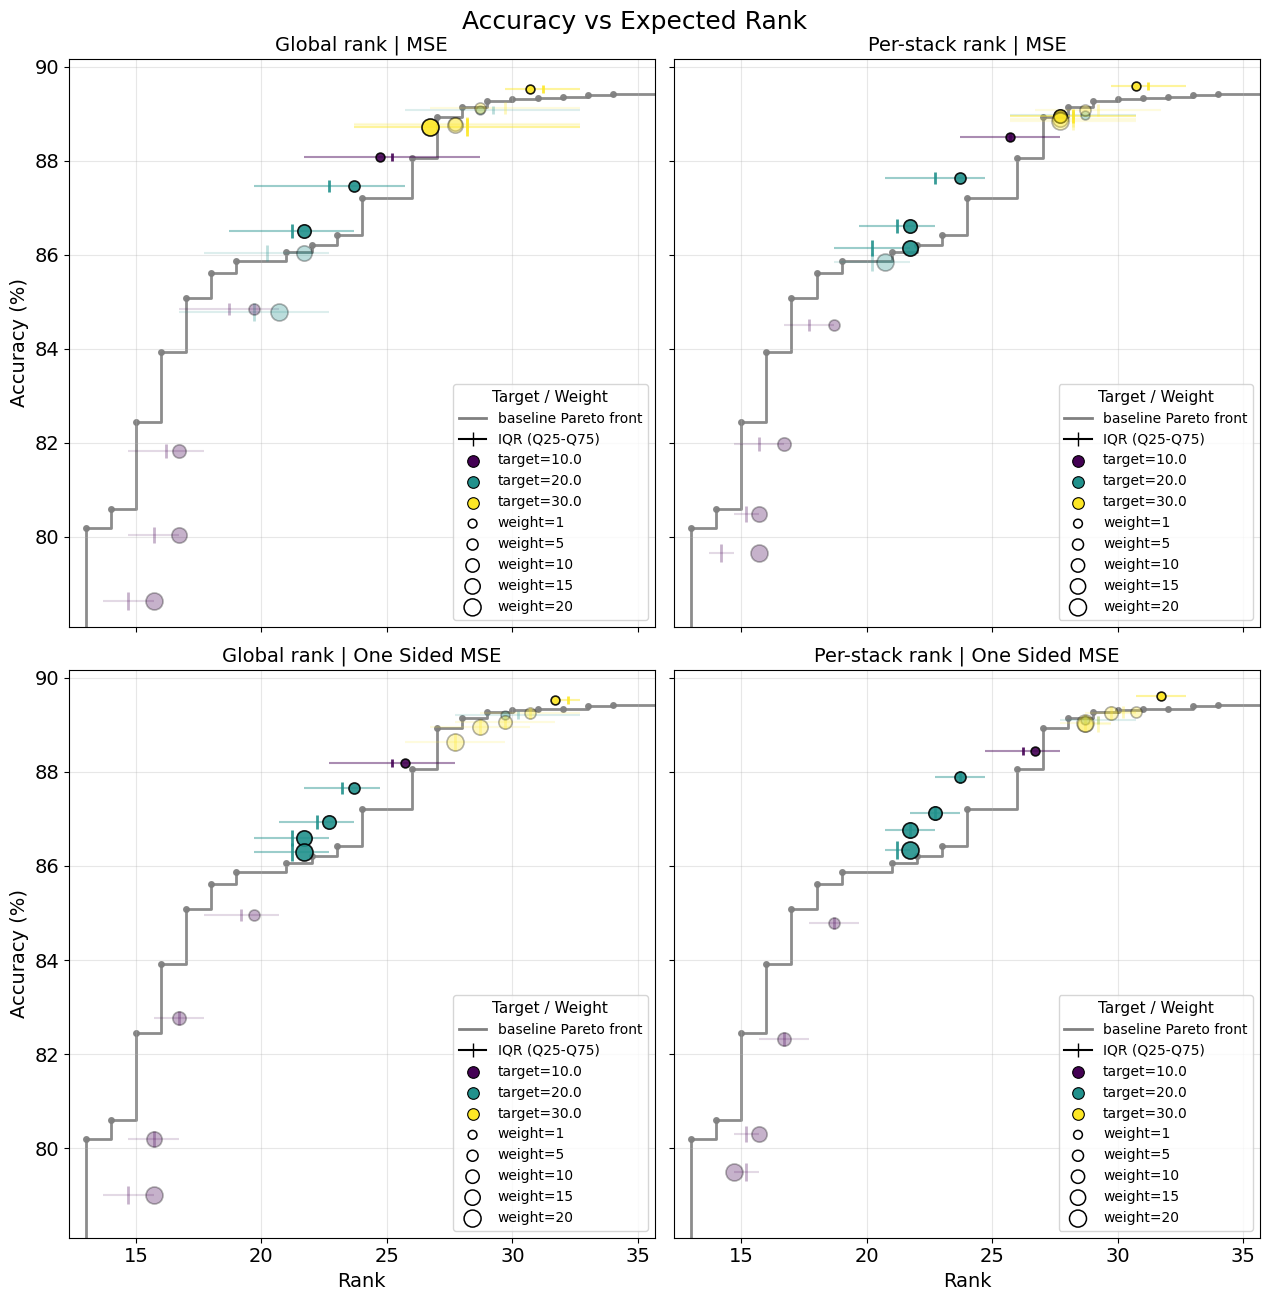

In [525]:
# Example usage + save figure (high DPI)
output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")
output_dir.mkdir(parents=True, exist_ok=True)

fig = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_3,
    include_router_overhead=True,
    x_axis='rank',
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(13, 35),
    plot_title='Accuracy vs Expected Rank',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / "rank_vs_accuracy_pareto_targeted_losses.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')
print(f"Saved figure to: {save_path}")